# Naive Bayes from Scratch 📊

In this notebook, we implement **Gaussian Naive Bayes**, a probabilistic classifier based on applying Bayes' theorem with strong (naive) independence assumptions between the features.

## 📖 Theoretical Background

Bayes' Theorem states:
$$P(y|X) = \frac{P(X|y)P(y)}{P(X)}$$

Since we assume features are independent, the likelihood $P(X|y)$ becomes:
$$P(X|y) = \prod_{i=1}^{n} P(x_i|y)$$

For **Gaussian Naive Bayes**, we assume continuous features follow a normal (Gaussian) distribution. The probability density of $x_i$ given class $y$ is:
$$P(x_i|y) = \frac{1}{\sqrt{2\pi\sigma_y^2}} \exp\left(-\frac{(x_i - \mu_y)^2}{2\sigma_y^2}\right)$$

To prevent underflow, we compute the log probability:
$$\log P(y|X) \propto \log P(y) + \sum_{i=1}^{n} \log P(x_i|y)$$
We predict the class $y$ that maximizes this posterior probability.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

np.random.seed(42)

## 🏗️ The Implementation

In [2]:
class GaussianNB:
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        n_classes = len(self.classes)
        
        # Initialize arrays to store mean, variance, and priors per class
        self.mean = np.zeros((n_classes, n_features), dtype=np.float64)
        self.var = np.zeros((n_classes, n_features), dtype=np.float64)
        self.priors = np.zeros(n_classes, dtype=np.float64)
        
        for idx, c in enumerate(self.classes):
            X_c = X[y == c]
            self.mean[idx, :] = X_c.mean(axis=0)
            self.var[idx, :] = X_c.var(axis=0)
            self.priors[idx] = X_c.shape[0] / float(n_samples)
            
    def predict(self, X):
        y_pred = [self._predict(x) for x in X]
        return np.array(y_pred)
        
    def _predict(self, x):
        posteriors = []
        
        # Calculate posterior probability for each class
        for idx, c in enumerate(self.classes):
            prior = np.log(self.priors[idx])
            posterior = np.sum(np.log(self._pdf(idx, x)))
            posterior = prior + posterior
            posteriors.append(posterior)
            
        # Return class with highest posterior probability
        return self.classes[np.argmax(posteriors)]
        
    def _pdf(self, class_idx, x):
        mean = self.mean[class_idx]
        var = self.var[class_idx]
        numerator = np.exp(-((x - mean) ** 2) / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator

## 🧪 Data Generation and Training

In [3]:
X, y = make_classification(n_samples=300, n_features=2, n_informative=2, n_redundant=0, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

model = GaussianNB()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

accuracy = np.sum(predictions == y_test) / len(y_test)
print(f"Naive Bayes Accuracy: {accuracy * 100:.2f}%")

Naive Bayes Accuracy: 88.33%


## 📊 Visualization

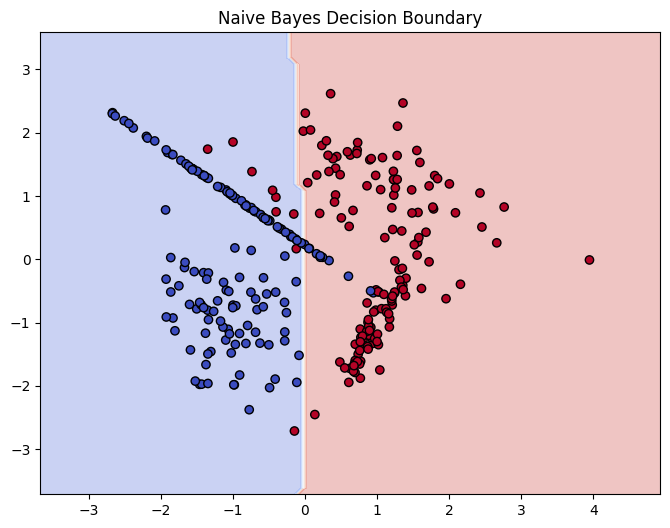

In [4]:
plt.figure(figsize=(8, 6))
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k")
plt.title("Naive Bayes Decision Boundary")
plt.show()

## 📊 Additional Visualizations

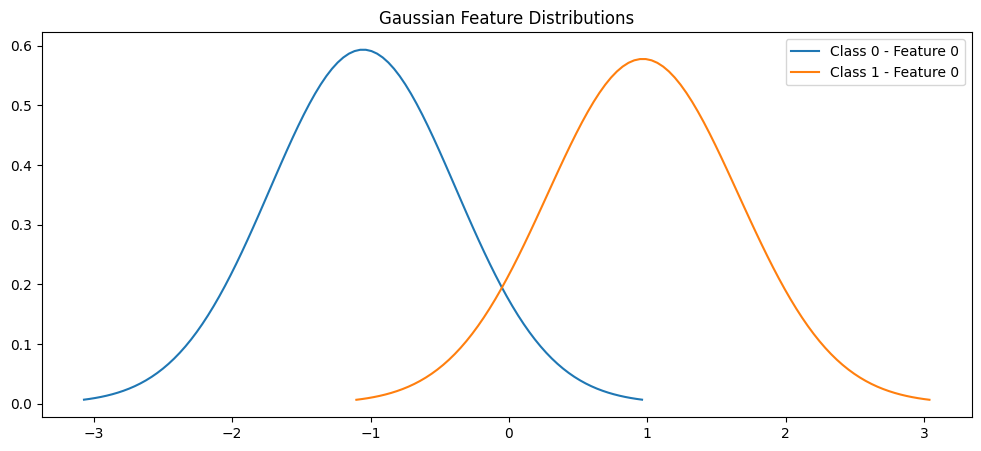

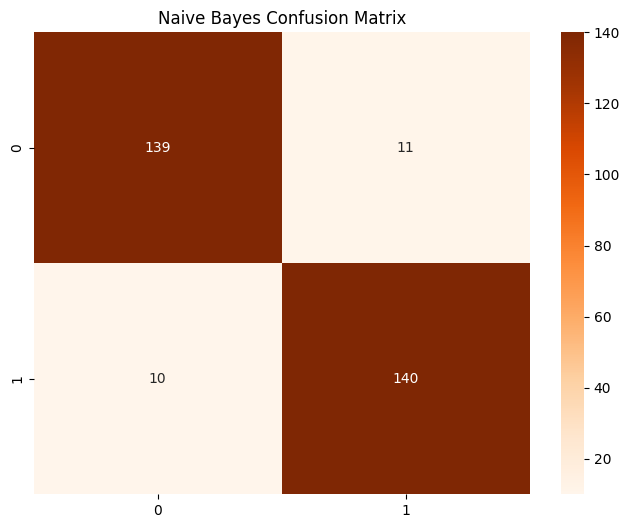

In [5]:

# 1. Gaussian Distributions for each feature and class
import scipy.stats as stats

plt.figure(figsize=(12, 5))
for i, c in enumerate(model.classes):
    mean = model.mean[i, 0]
    var = model.var[i, 0]
    x_axis = np.linspace(mean - 3*np.sqrt(var), mean + 3*np.sqrt(var), 100)
    plt.plot(x_axis, stats.norm.pdf(x_axis, mean, np.sqrt(var)), label=f'Class {c} - Feature 0')

plt.title('Gaussian Feature Distributions')
plt.legend()
plt.show()

# 2. Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(X)
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title('Naive Bayes Confusion Matrix')
plt.show()
